# **Image Based Animal Type Classification for Cow and Buffaloes**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/datasets"

print("Cow Images:", len(os.listdir(base_path+"/Cow")))
print("Buffalo Images:", len(os.listdir(base_path+"/Buffalo")))

Cow Images: 515
Buffalo Images: 515


In [5]:
import os
import random
import shutil

base_path = "/content/drive/MyDrive/Colab Notebooks/datasets"

os.makedirs(base_path+"/train/cow", exist_ok=True)
os.makedirs(base_path+"/train/buffalo", exist_ok=True)
os.makedirs(base_path+"/test/cow", exist_ok=True)
os.makedirs(base_path+"/test/buffalo", exist_ok=True)

def split_data(source, train, test, split_size=0.8):

    files = os.listdir(source)
    random.shuffle(files)

    split_point = int(len(files)*split_size)

    train_files = files[:split_point]
    test_files = files[split_point:]

    for file in train_files:
        shutil.copy(os.path.join(source,file), train)

    for file in test_files:
        shutil.copy(os.path.join(source,file), test)

split_data(base_path+"/Cow", base_path+"/train/cow", base_path+"/test/cow")
split_data(base_path+"/Buffalo", base_path+"/train/buffalo", base_path+"/test/buffalo")

print("Dataset Split Completed ✅")

Dataset Split Completed ✅


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/datasets"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_data = train_datagen.flow_from_directory(
    dataset_path+"/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    dataset_path+"/test",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

print(train_data.class_indices)

Found 824 images belonging to 2 classes.
Found 206 images belonging to 2 classes.
{'buffalo': 0, 'cow': 1}


In [9]:
model = Sequential()

# Block 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 4
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,602,113 (13.74 MB)

 Trainable params: 3,601,153 (13.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.7131 - loss: 1.9639 - val_accuracy: 0.6262 - val_loss: 0.7763
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8409 - loss: 0.7789 - val_accuracy: 0.5000 - val_loss: 4.6949
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8560 - loss: 0.5442 - val_accuracy: 0.5340 - val_loss: 1.2833
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8934 - loss: 0.3930 - val_accuracy: 0.5000 - val_loss: 1.8467
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8779 - loss: 0.3126 - val_accuracy: 0.5000 - val_loss: 1.8543
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.9228 - loss: 0.3164 - val_accuracy: 0.6845 - val_loss: 1.1476
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8996 - loss: 0.2816 - val_accuracy: 0.6068 - val_loss: 2.0897
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9145 - loss: 0.2307 - val_accuracy: 0.7136 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Prediction: Buffalo 🐃
Confidence: 100.0 %


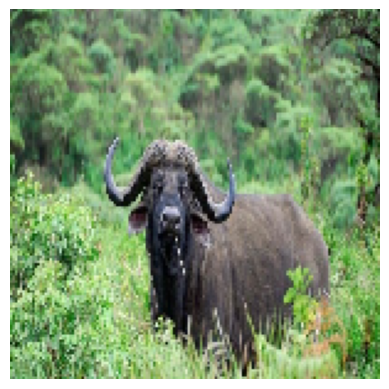

In [11]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path="/content/drive/MyDrive/Colab Notebooks/datasets/Buffalo/Buffalo_1.jpg"

img=image.load_img(img_path,target_size=(150,150))
img_array=image.img_to_array(img)

img_array=np.expand_dims(img_array,axis=0)
img_array=img_array/255.0

prediction=model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")

if prediction>0.5:
    print("Prediction: Cow 🐄")
    confidence=prediction
else:
    print("Prediction: Buffalo 🐃")
    confidence=1-prediction

print("Confidence:",round(confidence*100,2),"%")

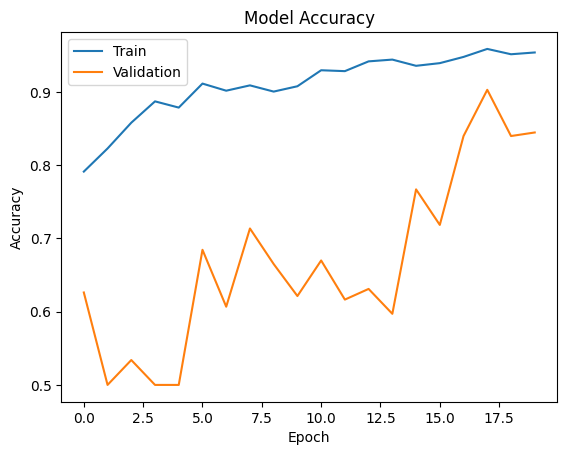

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [13]:
model.save("/content/drive/MyDrive/Colab Notebooks/cow_buffalo_classifier.h5")